# COVID-19 Confirmed Case Prediction for India — CLA 2


This notebook continues the original CLA 1 project and adds the MLOps concepts implemented in the Customer Churn Prediction Labs:

- **CLA 1:** Data loading, cleaning, feature engineering, EDA, 3 regression models, evaluation and prediction.
- **Lab 3:** Reproducible baseline ML pipeline, model persistence and model comparison.
- **Lab 4:** MLflow experiment tracking, parameters, metrics, artifacts and reproducibility.
- **Lab 5:** Production-style input validation, sklearn preprocessing pipeline and output validation.

> Run this notebook from the project root: `COVID19_MLOps_Final/`.


In [1]:
# 0. IMPORTS AND PROJECT SETUP

from pathlib import Path
import json
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import joblib

warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Find the project root reliably, even when the notebook is opened
# from the notebooks/ directory.

PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "data" / "full_grouped.csv").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "full_grouped.csv"

print("Project root:", PROJECT_ROOT)
print("Dataset:", DATA_PATH)
print("Dataset exists:", DATA_PATH.exists())
OUTPUT_DIR = PROJECT_ROOT / "outputs"
MODEL_DIR = PROJECT_ROOT / "models"
ARTIFACT_DIR = PROJECT_ROOT / "artifacts"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

for folder in [OUTPUT_DIR, MODEL_DIR, ARTIFACT_DIR, PROCESSED_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Dataset:", DATA_PATH)


Project root: c:\Users\SATVIK\OneDrive\Documents\MLOPS\COVID19_MLOps_Final
Dataset: c:\Users\SATVIK\OneDrive\Documents\MLOPS\COVID19_MLOps_Final\data\full_grouped.csv
Dataset exists: True
Project root: c:\Users\SATVIK\OneDrive\Documents\MLOPS\COVID19_MLOps_Final
Dataset: c:\Users\SATVIK\OneDrive\Documents\MLOPS\COVID19_MLOps_Final\data\full_grouped.csv


In [20]:
# 1. LOAD DATA

df = pd.read_csv(DATA_PATH)

print("DATA LOADED")
print("Shape:", df.shape)
display(df.head())


DATA LOADED
Shape: (35156, 10)


,Date,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,WHO Region
0,2020-01-22,Afghanistan,0,0,0,0,0,0,0,Eastern Mediterranean
1,2020-01-22,Albania,0,0,0,0,0,0,0,Europe
2,2020-01-22,Algeria,0,0,0,0,0,0,0,Africa
3,2020-01-22,Andorra,0,0,0,0,0,0,0,Europe
4,2020-01-22,Angola,0,0,0,0,0,0,0,Africa


In [3]:
# 2. UNDERSTAND DATA

print("Columns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
display(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())


Columns:
['Date', 'Country/Region', 'Confirmed', 'Deaths', 'Recovered', 'Active', 'New cases', 'New deaths', 'New recovered', 'WHO Region']

Data types:
Date                str
Country/Region      str
Confirmed         int64
Deaths            int64
Recovered         int64
Active            int64
New cases         int64
New deaths        int64
New recovered     int64
WHO Region          str
dtype: object

Missing values:


Date              0
Country/Region    0
Confirmed         0
Deaths            0
Recovered         0
Active            0
New cases         0
New deaths        0
New recovered     0
WHO Region        0
dtype: int64


Duplicate rows: 0


In [4]:
# 3. SELECT INDIA

df = df[df["Country/Region"] == "India"].copy()

print("India rows:", len(df))
display(df.head())


India rows: 188


,Date,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,WHO Region
79,2020-01-22,India,0,0,0,0,0,0,0,South-East Asia
266,2020-01-23,India,0,0,0,0,0,0,0,South-East Asia
453,2020-01-24,India,0,0,0,0,0,0,0,South-East Asia
640,2020-01-25,India,0,0,0,0,0,0,0,South-East Asia
827,2020-01-26,India,0,0,0,0,0,0,0,South-East Asia


In [5]:
# 4. CLEAN DATA

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df.dropna(subset=["Date"])
df = df.sort_values("Date").drop_duplicates()

number_columns = ["Confirmed", "Deaths", "Recovered", "Active", "New cases"]

for column in number_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")
    df[column] = df[column].fillna(0)

print("CLEANING COMPLETE")
display(df[number_columns].isnull().sum())


CLEANING COMPLETE


Confirmed    0
Deaths       0
Recovered    0
Active       0
New cases    0
dtype: int64

In [6]:
# 5. FEATURE ENGINEERING

# Yesterday's confirmed cases are used to predict today's confirmed cases.
df["Previous_Day_Confirmed"] = df["Confirmed"].shift(1)

df = df.dropna(subset=["Previous_Day_Confirmed"]).copy()

print("FEATURE ENGINEERING COMPLETE")
display(df[["Date", "Previous_Day_Confirmed", "Confirmed"]].head())


FEATURE ENGINEERING COMPLETE


,Date,Previous_Day_Confirmed,Confirmed
266,2020-01-23,0.0,0
453,2020-01-24,0.0,0
640,2020-01-25,0.0,0
827,2020-01-26,0.0,0
1014,2020-01-27,0.0,0


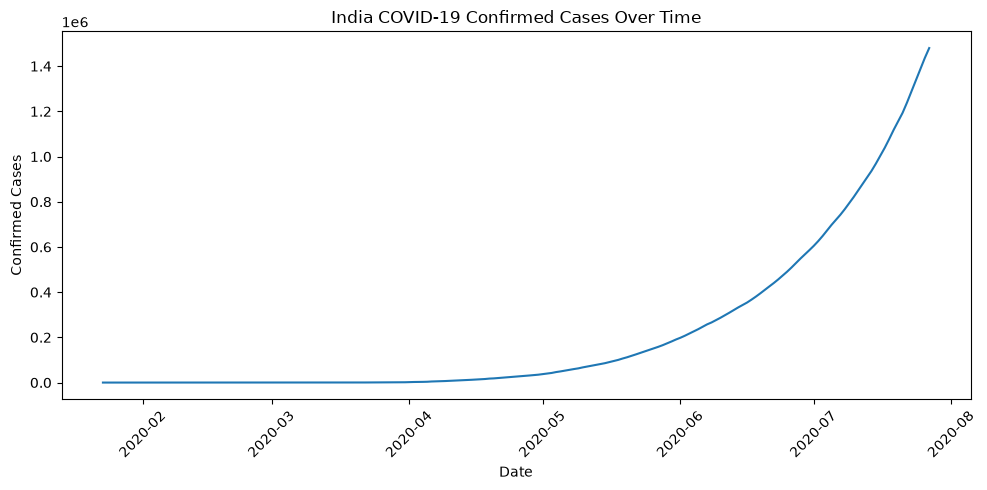

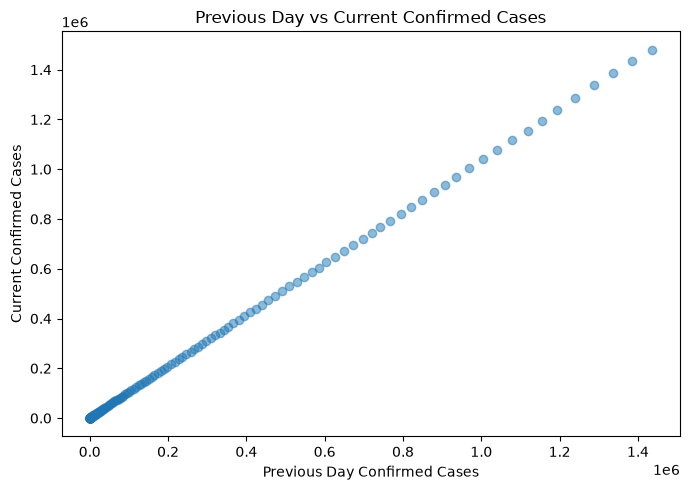

In [7]:
# 6. EDA

plt.figure(figsize=(10, 5))
plt.plot(df["Date"], df["Confirmed"])
plt.title("India COVID-19 Confirmed Cases Over Time")
plt.xlabel("Date")
plt.ylabel("Confirmed Cases")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confirmed_cases_over_time.png")
plt.show()

plt.figure(figsize=(7, 5))
plt.scatter(df["Previous_Day_Confirmed"], df["Confirmed"], alpha=0.5)
plt.title("Previous Day vs Current Confirmed Cases")
plt.xlabel("Previous Day Confirmed Cases")
plt.ylabel("Current Confirmed Cases")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "previous_day_relationship.png")
plt.show()


In [8]:
# 7. FEATURES AND TARGET

X = df[["Previous_Day_Confirmed"]]
y = df["Confirmed"]

print("Features:", X.columns.tolist())
print("Target: Confirmed")


Features: ['Previous_Day_Confirmed']
Target: Confirmed


In [9]:
# 8. CHRONOLOGICAL TRAIN / TEST SPLIT

# Keep time order to avoid future information leaking into the training set.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    shuffle=False
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))


Training rows: 149
Testing rows: 38


In [10]:
# 9. LAB 3 — BASELINE MODELS

linear_model = LinearRegression()

tree_model = DecisionTreeRegressor(
    max_depth=5,
    random_state=SEED
)

forest_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=8,
    random_state=SEED
)

models = {
    "Linear Regression": linear_model,
    "Decision Tree": tree_model,
    "Random Forest": forest_model
}

predictions = {}
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    prediction = model.predict(X_test)
    predictions[name] = prediction

    mae = mean_absolute_error(y_test, prediction)
    rmse = np.sqrt(mean_squared_error(y_test, prediction))
    r2 = r2_score(y_test, prediction)

    results.append([name, mae, rmse, r2])

results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "RMSE", "R2"]
)

display(results_df)


,Model,MAE,RMSE,R2
0,Linear Regression,3048.878174,3782.185845,0.999853
1,Decision Tree,442304.631579,541164.938255,-2.012149
2,Random Forest,451907.291579,549041.258434,-2.100467


In [19]:
# 10. LAB 3 — SAVE MODELS AND RESULTS

joblib.dump(linear_model, MODEL_DIR / "linear_regression.pkl")
joblib.dump(tree_model, MODEL_DIR / "decision_tree.pkl")
joblib.dump(forest_model, MODEL_DIR / "random_forest.pkl")

results_df.to_csv(OUTPUT_DIR / "model_comparison.csv", index=False)

test_predictions = pd.DataFrame({
    "Actual": y_test.values,
    "Linear_Regression": predictions["Linear Regression"],
    "Decision_Tree": predictions["Decision Tree"],
    "Random_Forest": predictions["Random Forest"]
})

test_predictions.to_csv(OUTPUT_DIR / "test_predictions.csv", index=False)

best_row = results_df.loc[results_df["RMSE"].idxmin()]
best_model_name = best_row["Model"]

print("Best model based on RMSE:", best_model_name)


Best model based on RMSE: Linear Regression


In [12]:
# 11. LAB 3 — SAMPLE PREDICTION

sample = pd.DataFrame({
    "Previous_Day_Confirmed": [1_000_000]
})

if best_model_name == "Linear Regression":
    sample_prediction = linear_model.predict(sample)[0]
elif best_model_name == "Decision Tree":
    sample_prediction = tree_model.predict(sample)[0]
else:
    sample_prediction = forest_model.predict(sample)[0]

print("Previous day confirmed cases:", 1_000_000)
print("Predicted confirmed cases:", round(sample_prediction))


Previous day confirmed cases: 1000000
Predicted confirmed cases: 1038896


## Lab 4 — MLflow Experiment Tracking

The following section tracks the same three models with:

- model parameters
- MAE, RMSE and R²
- model artifacts
- reproducibility information

The project uses the modern local SQLite MLflow backend (`mlflow.db`), which is compatible with current MLflow versions.


In [13]:
# 12. LAB 4 — MLflow TRACKING

import mlflow
import mlflow.sklearn

MLFLOW_DB = "sqlite:///mlflow.db"

mlflow.set_tracking_uri(MLFLOW_DB)
mlflow.set_experiment("COVID19_India_Regression")

mlflow_results = []

for name, model in models.items():
    # Refit so each MLflow run is self-contained.
    model.fit(X_train, y_train)
    prediction = model.predict(X_test)

    mae = mean_absolute_error(y_test, prediction)
    rmse = np.sqrt(mean_squared_error(y_test, prediction))
    r2 = r2_score(y_test, prediction)

    with mlflow.start_run(run_name=name.replace(" ", "_")):
        mlflow.log_param("model", name)
        mlflow.log_param("random_state", SEED)

        if name == "Decision Tree":
            mlflow.log_param("max_depth", 5)
        elif name == "Random Forest":
            mlflow.log_param("n_estimators", 100)
            mlflow.log_param("max_depth", 8)

        mlflow.log_metric("mae", mae)
        mlflow.log_metric("rmse", rmse)
        mlflow.log_metric("r2", r2)

        mlflow.sklearn.log_model(
            model,
            name="model",
            skops_trusted_types=["sklearn.tree._tree.Tree"]
        )

        mlflow_results.append([name, mae, rmse, r2])

print("MLflow tracking completed.")
display(pd.DataFrame(
    mlflow_results,
    columns=["Model", "MAE", "RMSE", "R2"]
))


MLflow tracking completed.


,Model,MAE,RMSE,R2
0,Linear Regression,3048.878174,3782.185845,0.999853
1,Decision Tree,442304.631579,541164.938255,-2.012149
2,Random Forest,451907.291579,549041.258434,-2.100467


In [14]:
# 13. LAB 4 — REPRODUCIBILITY CHECK

# Train the same Random Forest again with the same random seed
# and verify that its RMSE is identical.

rf_check = RandomForestRegressor(
    n_estimators=100,
    max_depth=8,
    random_state=SEED
)

rf_check.fit(X_train, y_train)
rf_check_prediction = rf_check.predict(X_test)

rf_check_rmse = np.sqrt(
    mean_squared_error(y_test, rf_check_prediction)
)

original_rf_rmse = results_df.loc[
    results_df["Model"] == "Random Forest", "RMSE"
].iloc[0]

print("Original Random Forest RMSE:", original_rf_rmse)
print("Re-run Random Forest RMSE:", rf_check_rmse)

if np.isclose(original_rf_rmse, rf_check_rmse):
    print("[SUCCESS] Reproducible.")
else:
    print("[WARNING] Results are not identical.")


Original Random Forest RMSE: 549041.2584336443
Re-run Random Forest RMSE: 549041.2584336443
[SUCCESS] Reproducible.


## Lab 5 — Production Data Pipeline

This section adds production-style checks:

1. Validate the input dataset.
2. Build a scikit-learn preprocessing pipeline.
3. Transform training and test data consistently.
4. Save the preprocessing artifact.
5. Validate the production outputs.


In [15]:
# 14. LAB 5 — INPUT DATA VALIDATION

required_columns = [
    "Date",
    "Country/Region",
    "Confirmed",
    "Deaths",
    "Recovered",
    "Active",
    "New cases"
]

missing_columns = [c for c in required_columns if c not in pd.read_csv(DATA_PATH).columns]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

raw_check = pd.read_csv(DATA_PATH)

if raw_check.empty:
    raise ValueError("Input dataset is empty.")

if raw_check["Date"].isna().all():
    raise ValueError("Date column contains no valid values.")

for column in ["Confirmed", "Deaths", "Recovered"]:
    if not pd.api.types.is_numeric_dtype(raw_check[column]):
        raise ValueError(f"{column} must be numeric.")

if raw_check["Confirmed"].dropna().lt(0).any():
    raise ValueError("Confirmed cumulative cases cannot be negative.")

print("[SUCCESS] Input data validation PASSED.")


[SUCCESS] Input data validation PASSED.


In [16]:
# 15. LAB 5 — PRODUCTION SKLEARN PREPROCESSING PIPELINE

production_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

X_train_processed = production_pipeline.fit_transform(X_train)
X_test_processed = production_pipeline.transform(X_test)

joblib.dump(
    production_pipeline,
    ARTIFACT_DIR / "production_preprocessing_pipeline.pkl"
)

print("[SUCCESS] Production sklearn preprocessing pipeline completed.")
print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)


[SUCCESS] Production sklearn preprocessing pipeline completed.
Processed training shape: (149, 1)
Processed testing shape: (38, 1)


In [17]:
# 16. LAB 5 — PRODUCTION OUTPUT VALIDATION

if X_train_processed.shape[0] != X_train.shape[0]:
    raise ValueError("Training row count changed unexpectedly.")

if X_test_processed.shape[0] != X_test.shape[0]:
    raise ValueError("Testing row count changed unexpectedly.")

if np.isnan(X_train_processed).any():
    raise ValueError("NaN values remain in processed training data.")

if np.isnan(X_test_processed).any():
    raise ValueError("NaN values remain in processed testing data.")

metadata = {
    "dataset": str(DATA_PATH),
    "feature_columns": X.columns.tolist(),
    "target": "Confirmed",
    "train_rows": int(len(X_train)),
    "test_rows": int(len(X_test)),
    "best_model_by_rmse": best_model_name,
    "random_seed": SEED
}

with open(PROCESSED_DIR / "dataset_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=4)

print("[SUCCESS] Production output validation PASSED.")


[SUCCESS] Production output validation PASSED.


In [18]:
# 17. FINAL PROJECT SUMMARY

print("=" * 60)
print("COVID-19 CLA 2 PROJECT SUMMARY")
print("=" * 60)

print("\nCLA 1:")
print("- Data loading and cleaning")
print("- India-only dataset")
print("- Previous-day feature engineering")
print("- EDA")
print("- Linear Regression, Decision Tree, Random Forest")
print("- MAE, RMSE and R2 evaluation")
print("- Sample prediction")

print("\nLAB 3:")
print("- Baseline pipeline")
print("- Model persistence")
print("- Model comparison")
print("- Reproducible random seed")

print("\nLAB 4:")
print("- MLflow experiment tracking")
print("- Parameters and metrics")
print("- Model artifacts")
print("- SQLite tracking database")
print("- Reproducibility check")

print("\nLAB 5:")
print("- Input validation")
print("- sklearn preprocessing pipeline")
print("- Saved preprocessing artifact")
print("- Production output validation")

print("\nBest model by RMSE:", best_model_name)
print("\n[SUCCESS] CLA 1 + Labs 3, 4 and 5 completed.")


COVID-19 CLA 2 PROJECT SUMMARY

CLA 1:
- Data loading and cleaning
- India-only dataset
- Previous-day feature engineering
- EDA
- Linear Regression, Decision Tree, Random Forest
- MAE, RMSE and R2 evaluation
- Sample prediction

LAB 3:
- Baseline pipeline
- Model persistence
- Model comparison
- Reproducible random seed

LAB 4:
- MLflow experiment tracking
- Parameters and metrics
- Model artifacts
- SQLite tracking database
- Reproducibility check

LAB 5:
- Input validation
- sklearn preprocessing pipeline
- Saved preprocessing artifact
- Production output validation

Best model by RMSE: Linear Regression

[SUCCESS] CLA 1 + Labs 3, 4 and 5 completed.
